In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
df_2024_1 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2024.01.csv', sep=';', decimal=',')
df_2024_2 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2024.02.csv', sep=';', decimal=',')
df_2025_1 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2025.01.csv', sep=';', decimal=',')
df_2025_2 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2025.02.csv', sep=';', decimal=',')

C:\Users\rodri\AppData\Local\Temp\ipykernel_9284\3716014408.py:3: DtypeWarning: Columns (0: Regiao - Sigla, 1: Estado - Sigla, 2: Municipio, 3: Revenda, 4: CNPJ da Revenda, 5: Nome da Rua, 6: Numero Rua, 7: Complemento, 8: Bairro, 9: Cep, 10: Produto, 11: Data da Coleta, 12: Unidade de Medida, 13: Bandeira) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2025_1 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2025.01.csv', sep=';', decimal=',')


In [22]:
# planilhas concatenadas

df = pd.concat([df_2024_1, df_2024_2,
df_2025_1, df_2025_2],
ignore_index=True)
print(df.shape)
display(df.head())

(1712267, 16)


,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
1,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA ADITIVADA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
2,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,DIESEL S10,01/01/2024,5.93,NaN,R$ / litro,VIBRA
3,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,ETANOL,01/01/2024,3.99,NaN,R$ / litro,VIBRA
4,NE,AL,ARAPIRACA,AUTO POSTO SAO FRANCISCO LTDA,12.706.529/0001-04,RUA SAO FRANCISCO,274,NaN,CENTRO,57300-080,GASOLINA,01/01/2024,5.48,NaN,R$ / litro,VIBRA


01
Construção da base consolidada
O sistema da ANP exporta os dados por semestre. Antes de qualquer análise, consolide os quatro arquivos de 2024 e 2025 
em um único DataFrame. Confirme que a operação foi realizada corretamente verificando o número de linhas e as 
primeiras entradas do resultado.

(1712267, 16)


,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
1,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA ADITIVADA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
2,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,DIESEL S10,01/01/2024,5.93,NaN,R$ / litro,VIBRA
3,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,ETANOL,01/01/2024,3.99,NaN,R$ / litro,VIBRA
4,NE,AL,ARAPIRACA,AUTO POSTO SAO FRANCISCO LTDA,12.706.529/0001-04,RUA SAO FRANCISCO,274,NaN,CENTRO,57300-080,GASOLINA,01/01/2024,5.48,NaN,R$ / litro,VIBRA


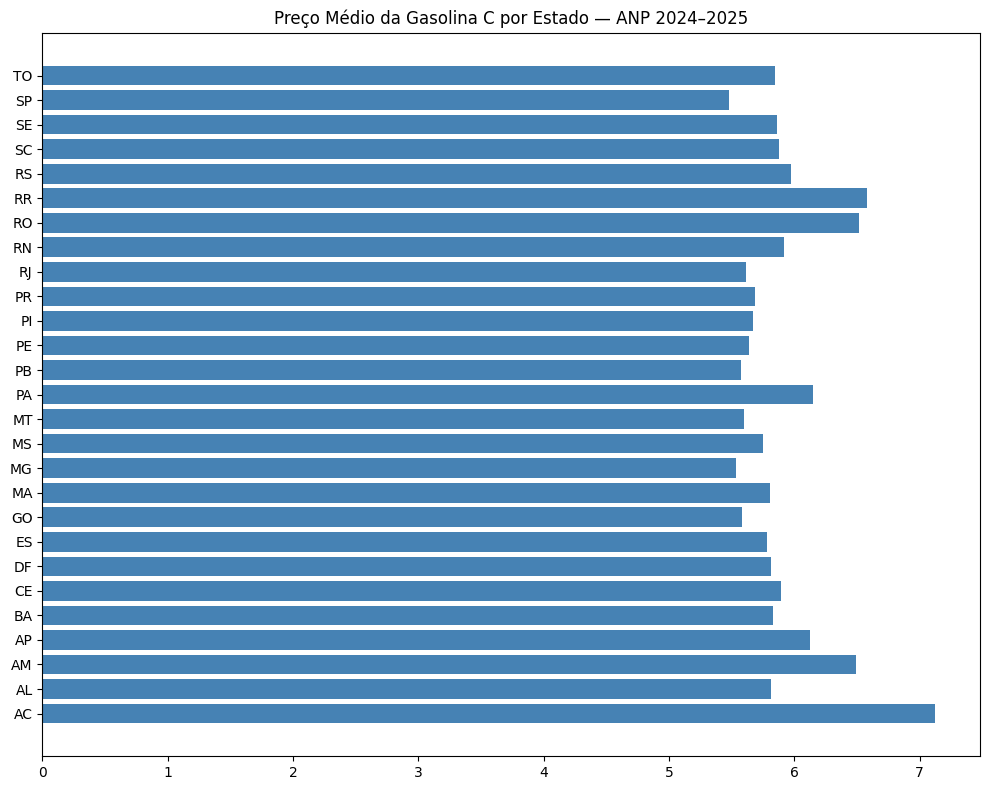

In [23]:
# Concatenação
df = pd.concat([df_2024_1, df_2024_2,
df_2025_1, df_2025_2],
ignore_index=True)

# Verificação
print(df.shape)
display(df.head())

# Gráfico
plt.figure(figsize=(10, 8))
#plt.barh(df['Estado - Sigla'],df['Valor de Venda'], color='steelblue')
plt.barh(df_estado.index, df_estado.values, color='steelblue') 
# df_estado = df.groupby('Estado - Sigla')['Valor de Venda'].mean()
plt.title('Preço Médio da Gasolina C por Estado — ANP 2024–2025')
plt.xticks(rotation=0)
#plt.xlabel('Preço Médio (R$)')
#plt.ylabel('Estado')
plt.tight_layout()
plt.show()



02
Gasolina C no Rio de Janeiro
O diretor quer entender como se comportaram os preços médios da Gasolina C no estado do Rio de Janeiro entre 2024 e 
2025. Calcule a média do Valor de Venda por município e apresente os resultados do maior para o menor. Quais municípios 
praticaram os maiores preços médios no período?

In [24]:
# Preco medio praticado no periodo
media_geral = df['Valor de Venda'].mean()
print(media_geral)
# Gráfico
plt.figure(figsize=(10, 8))
plt.barh(fat_estado['Estado - Sigla'], fat_estado['Valor de Venda'], color='steelblue')
plt.title('Preço Médio da Gasolina C por Estado — ANP 2024–2025')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



5.692053591192336


NameError: name 'fat_estado' is not defined

<Figure size 1000x800 with 0 Axes>

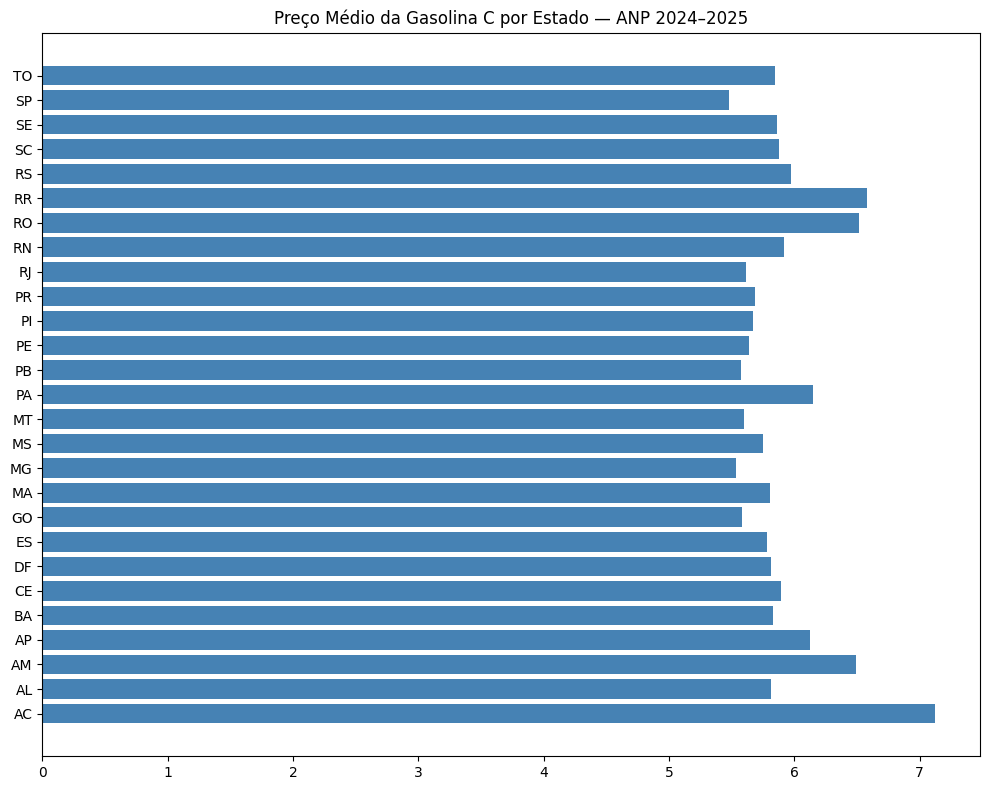

In [ ]:

# Preço médio por estado
estado_media = (
    df.groupby('Estado - Sigla')['Valor de Venda']
      .mean()
      .reset_index()
)

# Gráfico
plt.figure(figsize=(10, 8))
plt.barh(
    estado_media['Estado - Sigla'],
    estado_media['Valor de Venda'],
    color='steelblue'
)
plt.title('Preço Médio da Gasolina C por Estado — ANP 2024–2025')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

03
Outliers de preço: Gasolina C no RJ

Ainda com foco na Gasolina C no Rio de Janeiro, identifique os postos com preços estatisticamente atípicos. Calcule o IQR e 
os limites para o Valor de Venda. Existem postos praticando preços fora do padrão? Apresente os grupos de outliers 
superiores e inferiores ordenados de forma adequada. Se o limite inferior for negativo, o que isso indica?

In [ ]:
array_valor_outlier = np.array(df['Valor de Venda'])
q1 = np.percentile(array_valor_outlier, 25)
q3 = np.percentile(array_valor_outlier, 75)
iqr = q3 - q1
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)
#print(q1)
#print(q3)
print(f'Limite Superior: {limite_superior}')
print(f'Limite Inderiir: {limite_inferior}')


Limite Superior: nan
Limite Inderiir: nan


04
Comparando estados: Etanol Hidratado
O diretor quer comparar o preço médio do Etanol Hidratado entre RJ e SP em 2024 e 2025. Filtre os dados para os dois 
estados e calcule a média do Valor de Venda para cada um. Em seguida, aplique o critério de outliers em cada estado 
separadamente. Os limites e os casos atípicos são semelhantes ou diferentes entre os dois estados?

In [ ]:


df_rj_sp_etanol = df.loc[(df['Estado - Sigla'].isin(['RJ','SP'])) & (df['Produto'] =='ETANOL')]

df_media_eta_rjsp = df_media_eta_rjsp.groupby('Estado - Sigla')['Valor de Venda'].mean().reset_index()

df_media_eta_rjsp.sort_values(by='Valor de Venda', ascending=False,inplace=True)

df_media_eta_rjsp

NameError: name 'df_media_eta_rjsp' is not defined

05
Bairros da capital: preços dentro ou fora do padrão?
A diretoria quer entender como os preços da Gasolina C se distribuem entre os diferentes bairros da cidade do Rio de 
Janeiro. Existem bairros com dados atípicos?
A partir desse recorte:
1
Calcule a média do Valor de Venda por bairro (coluna Bairro) e ordene do maior para o menor.
2 Aplique o IQR para identificar bairros com preços médios estatisticamente atípicos — tanto os superiores quanto os 
inferiores.
3 Os bairros outliers superiores são regiões nobres da cidade? Os inferiores são periferias ou regiões com alta 
concorrência? Apresente sua conclusão.


In [ ]:
# Preco medio da Gasolina C por semana — ANP 2024-2025
preco_tempo = df_gas.groupby('Data da Coleta')['Valor de Venda'].mean()
plt.figure(figsize=(14, 4)) 
plt.plot(preco_tempo.index, preco_tempo.values, color='steelblue')
plt.title('Evolução do Preço Médio da Gasolina C — Brasil 2024–2025') 
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()


NameError: name 'df_gas' is not defined